# 01 | Baseline and Two-Stage Transfer Learning

This notebook builds a reusable `Food-101` training workflow, trains a `MobileNetV3-Large` baseline, and then compares two-stage transfer learning with `MobileNetV3-Large` and `ConvNeXt-Tiny`.

**Notebook outline**
- Inspect dataset size, class balance, and random samples
- Define train / validation transforms
- Build a stratified `LightningDataModule`
- Implement reusable `LightningModule` wrappers
- Train and evaluate the baseline
- Run Stage 1 head-only transfer learning
- Run Stage 2 fine-tuning on late feature blocks
- Save checkpoints, curves, prediction panels, and comparison figures


In [2]:
import copy
import os

import lightning.pytorch as pl
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, Subset
from torchmetrics.classification import Accuracy
from torchvision import datasets, transforms
from torchvision import models as tv_models

import random
from collections import defaultdict

torch.set_float32_matmul_precision('medium')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
pl.seed_everything(SEED, workers=True)

Seed set to 42


42

In [ ]:
import importlib
import matplotlib.pyplot as plt

import helper_utils
importlib.reload(helper_utils)
import utils
importlib.reload(utils)

## 1. Inspect the Dataset

Review the dataset structure, class balance, and random samples before building the training pipeline.


In [3]:
data_dir = "../data"

In [ ]:
# Check class counts across the dataset splits before training.
helper_utils.display_dataset_count(data_dir)


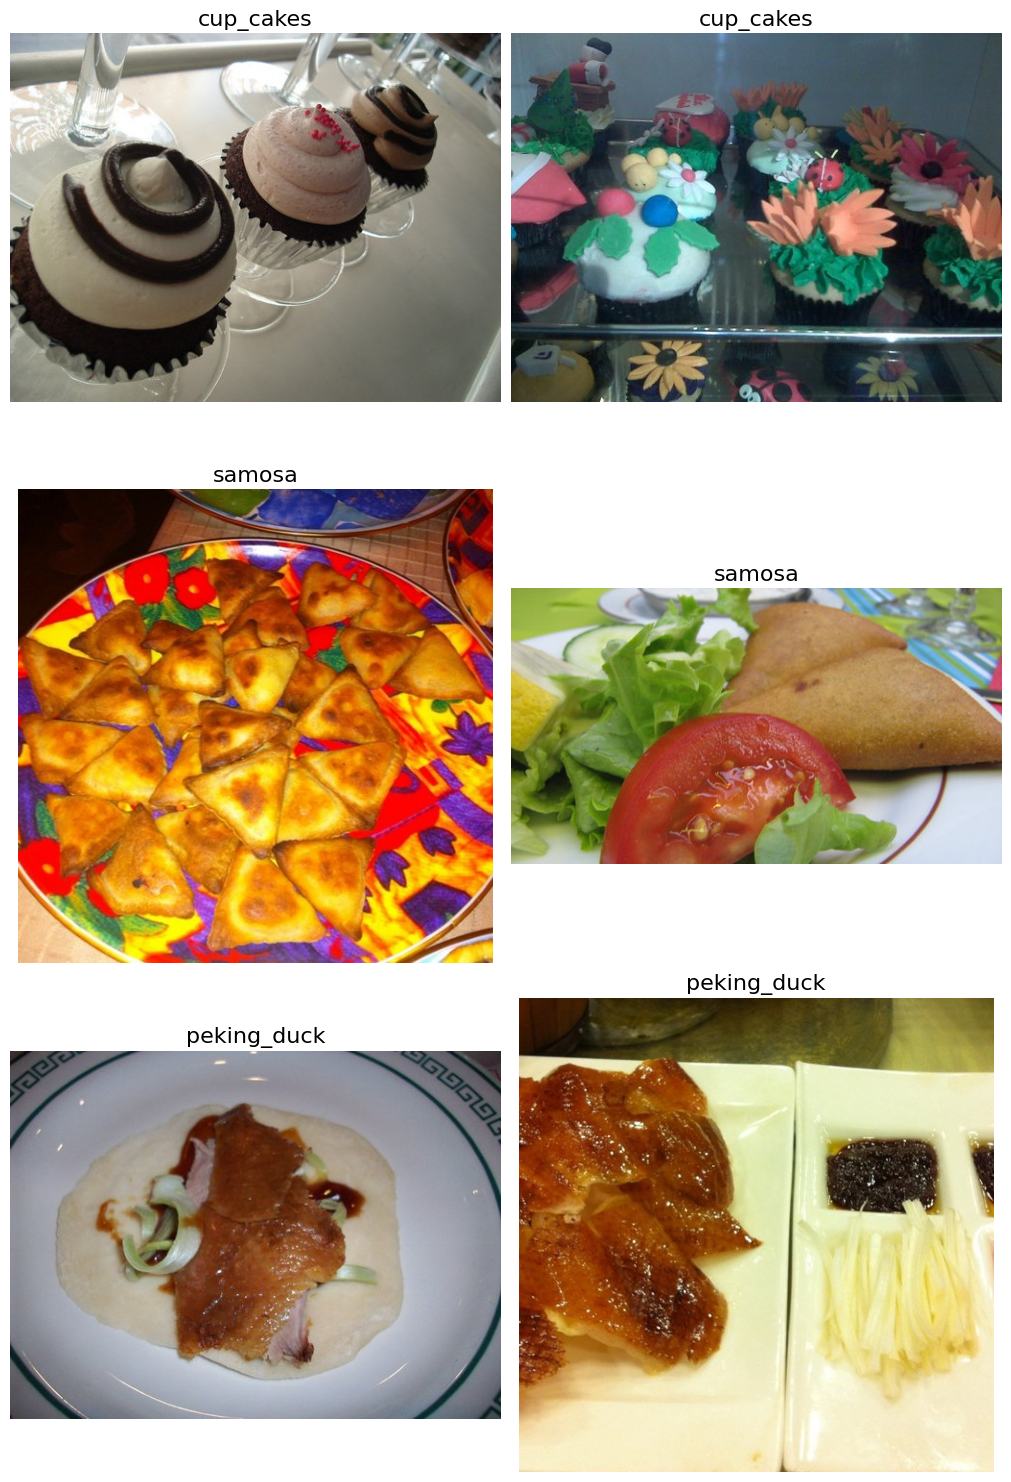

In [5]:
# Display a small random gallery from the training split for visual sanity checks.
helper_utils.display_random_images(data_dir)


## 2. Build the Data Pipeline

Create a reproducible, class-balanced train/validation split from the official `Food-101` training split while keeping the official test split untouched.


In [4]:
# Training-time image transforms.
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # Match ImageNet normalization because the backbones start from ImageNet weights.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transforms stay deterministic for fair evaluation.
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # Use the same ImageNet normalization as the pretrained backbone.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


We reserve `20%` of each class from the official training split for validation, so every split stays balanced across all `101` classes.

**Split sizes**
- Train: `600 × 101 = 60,600`
- Val: `150 × 101 = 15,150`
- Test: `250 × 101 = 25,250`


In [5]:
def create_datasets(data_dir, train_transform, val_transform, test_transform, seed=42):
    # Build two copies of the official training split so the train and
    # validation subsets can use different transforms while sharing the
    # same stratified index partition.
    train_source = datasets.Food101(
        root=data_dir,
        split="train",
        transform=train_transform,
        download=False
    )

    val_source = datasets.Food101(
        root=data_dir,
        split="train",
        transform=val_transform,
        download=False
    )

    # Keep the official test split untouched for final evaluation.
    test_dataset = datasets.Food101(
        root=data_dir,
        split="test",
        transform=test_transform,
        download=False
    )

    # Get the label for every sample in the training split.
    # Different torchvision versions may expose labels under different
    # attribute names, so we try the common options first.
    if hasattr(train_source, "_labels"):
        labels = train_source._labels
    elif hasattr(train_source, "targets"):
        labels = train_source.targets
    else:
        labels = [train_source[i][1] for i in range(len(train_source))]

    # Group sample indices by class label.
    # This keeps the validation split balanced across all 101 classes.
    label_to_indices = defaultdict(list)
    for idx, label in enumerate(labels):
        label_to_indices[label].append(idx)

    # Create a reproducible random generator so the same seed always
    # produces the same train/validation partition.
    g = torch.Generator().manual_seed(seed)

    train_indices = []
    val_indices = []

    # Shuffle indices inside each class separately, then reserve 20% of
    # each class for validation. This preserves class balance in both sets.
    for _, indices in label_to_indices.items():
        indices = torch.tensor(indices)
        perm = torch.randperm(len(indices), generator=g)
        indices = indices[perm].tolist()

        split_point = max(1, int(len(indices) * 0.2))
        val_indices.extend(indices[:split_point])
        train_indices.extend(indices[split_point:])

    # Wrap the selected indices with Subset objects.
    train_dataset = Subset(train_source, train_indices)
    val_dataset = Subset(val_source, val_indices)

    return train_dataset, val_dataset, test_dataset


In [6]:
def load_dataloader(train_dataset, val_dataset, test_dataset, batch_size, split, num_workers):
    # Select the correct dataset for the requested split.
    # Only the training loader should shuffle examples each epoch.
    if split == "train":
        dataset = train_dataset
        shuffle = True
    elif split == "val":
        dataset = val_dataset
        shuffle = False
    elif split == "test":
        dataset = test_dataset
        shuffle = False
    else:
        raise ValueError(f"Unsupported split: {split}")

    # Build the DataLoader with the chosen dataset and split-specific shuffle rule.
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers
    )

    return loader


In [7]:
# Inspect the available CPU count as a quick reference when choosing DataLoader workers.
# The final worker count can still be adjusted later based on notebook stability or throughput.
num_cpus = os.cpu_count()
print(f"Number of available CPU cores: {num_cpus}")

Number of available CPU cores: 14


In [8]:
class Food101DataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=64, num_workers=8, seed=42):
        super().__init__()

        # Keep constructor arguments on the module for reproducible data loading.
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.seed = seed

        # Reuse the global transforms defined above.
        self.train_transform = TRAIN_TRANSFORM
        self.val_transform = VAL_TRANSFORM
        self.test_transform = VAL_TRANSFORM

        # Datasets are created lazily inside `setup`.
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        
    
    def setup(self, stage=None):
        if self.train_dataset is None and self.val_dataset is None and self.test_dataset is None:
            # Build the stratified train/val split once and reuse it across trainer calls.
            self.train_dataset, self.val_dataset, self.test_dataset = create_datasets(
                data_dir=self.data_dir,
                train_transform=self.train_transform,
                val_transform=self.val_transform,
                test_transform=self.test_transform,
                seed=self.seed
            )
    
    def train_dataloader(self):
        # Create the shuffled training loader.
        train_loader = load_dataloader(
            self.train_dataset,
            self.val_dataset,
            self.test_dataset,
            batch_size=self.batch_size,
            split="train",
            num_workers=self.num_workers
        )

        return train_loader


    def val_dataloader(self):
        # Create the deterministic validation loader.
        val_loader = load_dataloader(
            self.train_dataset,
            self.val_dataset,
            self.test_dataset,
            batch_size=self.batch_size,
            split="val",
            num_workers=self.num_workers
        )

        return val_loader

    
    def test_dataloader(self):
        # Create the deterministic test loader.
        test_loader = load_dataloader(
            self.train_dataset,
            self.val_dataset,
            self.test_dataset,
            batch_size=self.batch_size,
            split="test",
            num_workers=self.num_workers
        )

        return test_loader


In [9]:
# Instantiate the DataModule for verification.
dm_verify = Food101DataModule(data_dir=data_dir, batch_size=64, num_workers=8, seed=42)
# Set up the datasets.
dm_verify.setup()
train_loader_verify = dm_verify.train_dataloader()
val_loader_verify = dm_verify.val_dataloader()
test_loader_verify = dm_verify.test_dataloader()

# --- Verify the Training Set ---
print("--- Training Set ---")
print(f"Total samples in the training dataset:    {len(dm_verify.train_dataset)}")
print(f"DataLoader batch size:                    {train_loader_verify.batch_size}")
print(f"DataLoader length (number of batches):    {len(train_loader_verify)}")

# --- Verify the Validation Set ---
print("\n--- Validation Set ---")
print(f"Total samples in the validation dataset:  {len(dm_verify.val_dataset)}")
print(f"DataLoader batch size:                    {val_loader_verify.batch_size}")
print(f"DataLoader length (number of batches):    {len(val_loader_verify)}")

# --- Verify the Test Set ---
print("\n--- Test Set ---")
print(f"Total samples in the test dataset:        {len(dm_verify.test_dataset)}")
print(f"DataLoader batch size:                    {test_loader_verify.batch_size}")
print(f"DataLoader length (number of batches):    {len(test_loader_verify)}")

--- Training Set ---
Total samples in the training dataset:    60600
DataLoader batch size:                    64
DataLoader length (number of batches):    947

--- Validation Set ---
Total samples in the validation dataset:  15150
DataLoader batch size:                    64
DataLoader length (number of batches):    237

--- Test Set ---
Total samples in the test dataset:        25250
DataLoader batch size:                    64
DataLoader length (number of batches):    395


## 3. Build the Baseline `LightningModule`

Package the model, loss, metrics, optimizer, and scheduler into a reusable training module.


### 3.1 Define the Backbone and Optimization

Start from a pretrained `MobileNetV3-Large`, replace the classifier head, and define the optimizer / scheduler pair used throughout the notebook.


In [10]:
def load_mobilenetV3_large(num_classes):
    # Initialize a MobileNetV3-Large with pre-trained weights.
    weights = tv_models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model = tv_models.mobilenet_v3_large(weights=weights)

    # Replace the classifier head to match the number of classes for the new task.
    num_ftrs = model.classifier[-1].in_features
    new_classifier = nn.Linear(in_features=num_ftrs, out_features=num_classes)
    model.classifier[-1] = new_classifier

    return model
    

In [11]:
def define_optimizer_and_scheduler(model, learning_rate, weight_decay):
    # AdamW is used for both baseline training and fine-tuning in this notebook.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    
    # Lower the learning rate when validation loss stops improving.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,  # reduce LR by 10x
        patience=2   # wait two flat validation epochs before lowering LR
    )
    
    return optimizer, scheduler


In [12]:
class Food101Classifier(pl.LightningModule):
    def __init__(self, num_classes=101, learning_rate=1e-3, weight_decay=1e-4):
        super().__init__()
        # Store constructor arguments in `self.hparams` for checkpoint reloads.
        self.save_hyperparameters()

        # Build the pretrained backbone and swap in a Food-101 classifier head.
        self.model = load_mobilenetV3_large(self.hparams.num_classes)
        self.loss_fn = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.num_classes)


    def forward(self, x):
        return self.model(x)

    
    def training_step(self, batch, batch_idx=None):
        # Unpack one batch and compute the training loss.
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss


    def validation_step(self, batch, batch_idx=None):
        # Compute validation loss and accuracy for the current batch.
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = self.accuracy(logits, y)

        # Log epoch-level validation metrics for checkpointing and plotting.
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_step=False, on_epoch=True)


    def configure_optimizers(self):
        # Reuse the notebook-wide optimizer / scheduler helper.
        optimizer, scheduler = define_optimizer_and_scheduler(
            self.model,
            self.hparams.learning_rate,
            self.hparams.weight_decay
        ) 
        
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}


In [13]:
verify_model = Food101Classifier()

# Get the optimizer and scheduler.
optimizer_config = verify_model.configure_optimizers()
optimizer = optimizer_config["optimizer"]
scheduler = optimizer_config["lr_scheduler"]["scheduler"]

# --- Print the results to verify ---
print("--- LightningModule Components ---")
print(f"Model Architecture: {verify_model.model.__class__.__name__}")
print(f"Classifier Head:    {verify_model.model.classifier[-1]}")
print(f"Loss Function:      {verify_model.loss_fn.__class__.__name__}")
print(f"Accuracy Metric:    {verify_model.accuracy.__class__.__name__}(num_classes={verify_model.accuracy.num_classes})")
print(f"Optimizer:          {optimizer.__class__.__name__}")
print(f"LR Scheduler:       {scheduler.__class__.__name__}")

--- LightningModule Components ---
Model Architecture: MobileNetV3
Classifier Head:    Linear(in_features=1280, out_features=101, bias=True)
Loss Function:      CrossEntropyLoss
Accuracy Metric:    MulticlassAccuracy(num_classes=101)
Optimizer:          AdamW
LR Scheduler:       ReduceLROnPlateau


## 4. Train and Evaluate the Baseline

Configure checkpointing and logging, run a short verification pass, and then launch the full baseline training run.


In [17]:
# Save only the best baseline checkpoint, using validation accuracy as the selection criterion.
checkpoint_callback = ModelCheckpoint(
    dirpath="../artifacts/checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="food101-baseline-{epoch:02d}-{val_acc:.4f}"
)

In [18]:
# Record baseline epoch-level metrics so the learning curves can be reloaded later.
csv_logger = CSVLogger(
    save_dir="../artifacts/logs",
    name="food101_baseline"
)


In [14]:
def run_training(model, data_module, num_epochs, callback=None, logger = None, progress_bar=True, dry_run=False, callbacks=None):
    trainer_callbacks = []
    if callback is not None:
        trainer_callbacks.append(callback)
    if callbacks is not None:
        trainer_callbacks.extend(callbacks)

    # Configure a reusable Lightning trainer for both smoke tests and full runs.
    trainer = pl.Trainer(
        max_epochs=num_epochs,
        accelerator="auto",
        devices=1,
        precision="16-mixed" if torch.backends.mps.is_available() else "32-true",
        callbacks=trainer_callbacks,

        # Attach the CSV logger so metrics are persisted under `artifacts/logs/`.
        logger=logger,
        enable_progress_bar=progress_bar,
        enable_model_summary=False,
        enable_checkpointing=True,
        # `fast_dev_run=True` runs a minimal end-to-end sanity check through fit.
        fast_dev_run=dry_run
    )

    trainer.fit(model, datamodule=data_module)

    return trainer, model

In [ ]:
verify_dm = Food101DataModule(data_dir=data_dir, batch_size=2)
verify_model = Food101Classifier()
num_epochs=1
verify_callback = checkpoint_callback

# Call the run_training function with dry_run=True.
print("--- Verifying Training Run (Dry Run) ---")
trainer, verify_model = run_training(
    model=verify_model,
    data_module=verify_dm,
    num_epochs=num_epochs,
    callback=verify_callback,
    dry_run=True
)
print("The Trainer configured and ran a single batch without errors.")

In [20]:
# Keep the first baseline intentionally short.
# The goal here is to verify that the full training loop behaves as expected.
training_epochs = 5

In [ ]:
# Build the full baseline training stack.
dm = Food101DataModule(data_dir=data_dir)
dm.setup()

# Recreate the baseline LightningModule.
model = Food101Classifier()

# Train the baseline while logging metrics and saving the best checkpoint.
trained_trainer, trained_model = run_training(
    model, dm, training_epochs, checkpoint_callback, csv_logger
)

print("
--- Training Complete ---")


In [ ]:
# Report which checkpoint achieved the highest validation accuracy during baseline training.
print("Best checkpoint:")
print(trained_trainer.checkpoint_callback.best_model_path)

# Report the corresponding best validation accuracy tracked by the checkpoint callback.
print("\nBest val_acc:")
print(trained_trainer.checkpoint_callback.best_model_score)

In [23]:
# Reload the best checkpoint and evaluate it once more on the validation set.
# This gives us a clean validation summary for the best saved model.
best_ckpt_path = trained_trainer.checkpoint_callback.best_model_path

best_model = Food101Classifier.load_from_checkpoint(best_ckpt_path)

val_results = trained_trainer.validate(best_model, datamodule=dm)
print(val_results)

Validation DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [00:22<00:00, 10.66it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.7174917459487915
        val_loss             1.068281650543213
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'val_loss': 1.068281650543213, 'val_acc': 0.7174917459487915}]


## 5. Review Baseline Results

Summarize the baseline run with plots and qualitative validation predictions that can be reused in the final report.


In [15]:
# Reload the CSVLogger output so the baseline training curves can be plotted from disk.
df = pd.read_csv("../artifacts/logs/food101_baseline/version_0/metrics.csv")

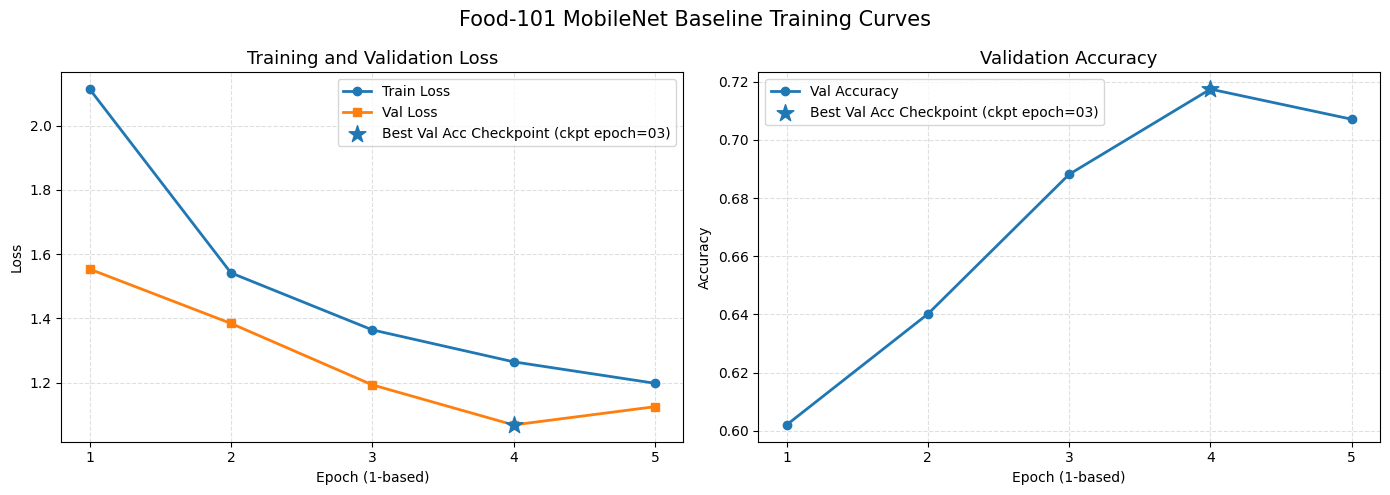

In [16]:
# Plot the baseline learning curves from the logged metrics dataframe.
baseline_curves_fig, baseline_curves_axes = helper_utils.plot_training_curves(
    df=df,
    title="Food-101 MobileNet Baseline Training Curves",
)

In [ ]:
# Save the baseline curve figure explicitly so the save step does not depend on
# Matplotlib's current active figure state.
helper_utils.save_figure_to_artifacts("mobilenet_baseline_training_curves", fig=baseline_curves_fig)

### 5.1 Inspect Random Validation Predictions

Sample a few validation images and compare the model's prediction against the ground-truth class label.

In [ ]:
# Visualize a fixed random sample of validation predictions from the best baseline checkpoint.
fig, axes = helper_utils.show_random_validation_predictions(best_model, dm, random_seed=42)

# Save the qualitative prediction panel alongside the curve figure.
helper_utils.save_figure_to_artifacts("mobilenet_baseline_val_predictions", fig=fig)

# The saved figure can be reused in the final report even if notebook output is cleared.


## 6. MobileNetV3 Two-Stage Transfer Learning

The baseline gives us a reference point, but Food-101 should benefit much more from transfer learning because `MobileNetV3-Large` already contains useful ImageNet features. In this section we reuse those pretrained features in two steps so we can separate the gains from a new classifier head and the gains from deeper fine-tuning.


### Strategy

- **Stage 1** freezes the pretrained backbone and trains only the classifier head.
- **Stage 2** starts from the Stage 1 checkpoint, unfreezes late feature blocks, and fine-tunes them with a smaller learning rate.


In [73]:
def load_mobilenetV3_large_2stage_tl(num_classes):
    # Initialize a MobileNetV3-Large with pre-trained weights.
    weights = tv_models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model = tv_models.mobilenet_v3_large(weights=weights)

    # Replace the classifier head to match the number of classes for the new task.
    num_ftrs = model.classifier[-1].in_features
    new_classifier = nn.Linear(in_features=num_ftrs, out_features=num_classes)
    model.classifier[-1] = new_classifier

    # Freeze all the parameters in the model.
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze ONLY the parameters of the new classifier head.
    for param in model.classifier[-1].parameters():
        param.requires_grad = True

    return model

In [20]:
# Build a standalone Stage 1 backbone so we can inspect the freeze / unfreeze setup.

stage1_model = load_mobilenetV3_large_2stage_tl(num_classes=101)
# Keep the full print optional because the complete MobileNetV3 architecture is long.
# print(stage1_model)

In [21]:
# Verify that an early feature block remains frozen in Stage 1.
print(f"Parameters in features[0] are frozen:       {not stage1_model.features[0][0].weight.requires_grad}")

# Verify that late backbone blocks are still frozen because Stage 1 trains only the head.
print(f"Parameters in features[12] are frozen:      {not stage1_model.features[12].block[0][0].weight.requires_grad}")

# Verify that the classifier head is trainable.
print(f"Parameters in the classifier are unfrozen:  {stage1_model.classifier[-1].weight.requires_grad}")


Parameters in features[0] are frozen:       True
Parameters in features[12] are unfrozen:    False
Parameters in the classifier are unfrozen:  True


In [22]:
# Wrap the Stage 1 model factory inside the reusable LightningModule helper so
# later experiments can reuse the same optimization and logging interface.
stage1_classifier = utils.Create_flexible_Food101Classifier(
    num_classes=101,
    learning_rate=1e-3,
    weight_decay=1e-4,
    load_model_fn=load_mobilenetV3_large_2stage_tl,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
)

In [23]:
# Confirm that the reusable LightningModule exposes the expected model,
# metric, optimizer, and scheduler before launching Stage 1 training.
verify_model = stage1_classifier

# Get the optimizer and scheduler.
optimizer_config = verify_model.configure_optimizers()
optimizer = optimizer_config["optimizer"]
scheduler = optimizer_config["lr_scheduler"]["scheduler"]

# --- Print the results to verify ---
print("--- LightningModule Components ---")
print(f"Model Architecture: {verify_model.model.__class__.__name__}")
print(f"Classifier Head:    {verify_model.model.classifier[-1]}")
print(f"Loss Function:      {verify_model.loss_fn.__class__.__name__}")
print(f"Accuracy Metric:    {verify_model.accuracy.__class__.__name__}(num_classes={verify_model.accuracy.num_classes})")
print(f"Optimizer:          {optimizer.__class__.__name__}")
print(f"LR Scheduler:       {scheduler.__class__.__name__}")

--- LightningModule Components ---
Model Architecture: MobileNetV3
Classifier Head:    Linear(in_features=1280, out_features=101, bias=True)
Loss Function:      CrossEntropyLoss
Accuracy Metric:    MulticlassAccuracy(num_classes=101)
Optimizer:          AdamW
LR Scheduler:       ReduceLROnPlateau


### 6.1 Stage 1: Train the Classifier Head

This stage is intentionally conservative. Only the new classifier learns, so the model can adapt to Food-101 labels quickly while the pretrained backbone remains fixed.


In [27]:
# Save only the best Stage 1 checkpoint, using validation accuracy as the selection criterion.
checkpoint_callback_tl_stage1 = ModelCheckpoint(
    dirpath="../artifacts/checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="food101-tl-stage1-{epoch:02d}-{val_acc:.4f}"
)

In [28]:
# Record Stage 1 epoch-level metrics so the learning curves can be reloaded and plotted later.
csv_logger_tl_stage1 = CSVLogger(
    save_dir="../artifacts/logs",
    name="food101_tl_stage1"
)

In [ ]:
# Run a one-batch dry run before the real Stage 1 training loop.
# Using a deep-copied model keeps this sanity check from mutating the actual
# classifier module that will be used for the full experiment.
verify_dm = Food101DataModule(data_dir=data_dir, batch_size=2)
verify_model = copy.deepcopy(stage1_classifier)
num_epochs = 1
verify_callback = checkpoint_callback_tl_stage1

# `dry_run=True` executes only a single batch, which is a fast way to catch
# shape, dataloader, and callback issues before spending time on training.
print("--- Verifying Training Run (Dry Run) ---")
trainer, verify_model = run_training(
    model=verify_model,
    data_module=verify_dm,
    num_epochs=num_epochs,
    callback=verify_callback,
    dry_run=True
)
print("The Trainer configured and ran a single batch without errors.")

In [29]:
# The purpose of Stage 1 is to allow the classification head to adapt to the data first.
# For Food-101 + pre-trained MobileNetV3-Large, this stage usually doesn't take too long.
training_epochs = 8

In [ ]:
# Build the full Stage 1 training stack: datamodule, model, checkpointing, and logging.
# In this stage only the classifier head trains, so the logged metrics describe
# how well the new head adapts while the pretrained backbone stays frozen.
dm = Food101DataModule(data_dir=data_dir)
dm.setup()

# Reuse the prepared Stage 1 LightningModule.
model = stage1_classifier

# Launch the full Stage 1 fit and keep both the Trainer and the fitted model.
trained_trainer_tl_stage1, trained_model_tl_stage1 = run_training(
    model, dm, training_epochs, checkpoint_callback_tl_stage1, csv_logger_tl_stage1
)

print("\n--- Training Complete ---")

In [ ]:
# Report which checkpoint achieved the highest validation accuracy during Stage 1 training.
print("Best checkpoint:")
print(trained_trainer_tl_stage1.checkpoint_callback.best_model_path)

# Report the corresponding best validation accuracy tracked by the checkpoint callback.
print("\nBest val_acc:")
print(trained_trainer_tl_stage1.checkpoint_callback.best_model_score)

In [42]:
# Reload the best checkpoint and evaluate it once more on the validation set.
# This gives us a clean validation summary for the best saved model.
best_ckpt_path = trained_trainer_tl_stage1.checkpoint_callback.best_model_path

best_model = type(stage1_classifier).load_from_checkpoint(
    best_ckpt_path,
    load_model_fn=load_mobilenetV3_large_2stage_tl,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
    num_classes=101,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

val_results = trained_trainer_tl_stage1.validate(best_model, datamodule=dm)
print(val_results)

Validation DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [00:22<00:00, 10.43it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.5958415865898132
        val_loss            1.6044135093688965
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'val_loss': 1.6044135093688965, 'val_acc': 0.5958415865898132}]


### 6.2 Review Stage 1 Curves

Inspect the Stage 1 learning curves before moving to fine-tuning. This helps confirm that the classifier head has learned useful Food-101 decision boundaries and that the best checkpoint is a sensible Stage 2 starting point.


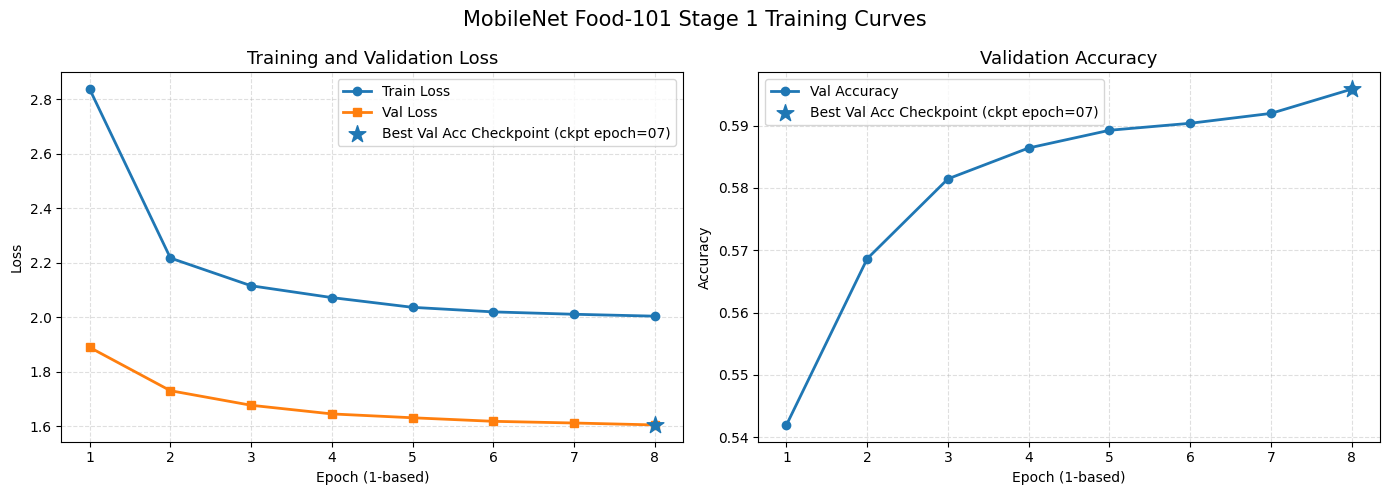

In [25]:
# Reload the Stage 1 CSV logs from disk so the curves can be recreated even
# after a kernel restart or after clearing notebook outputs.
df = pd.read_csv("../artifacts/logs/food101_tl_stage1/version_0/metrics.csv")

# Plot training loss, validation loss, and validation accuracy for the head-only run.
stage1_curves_fig, stage1_curves_axes = helper_utils.plot_training_curves(
    df=df,
    title="MobileNet Food-101 Stage 1 Training Curves",
)

In [ ]:
# Save the Stage 1 curve figure explicitly so the save step remains robust.
helper_utils.save_figure_to_artifacts("mobilenet_stage1_training_curves", fig=stage1_curves_fig)

### 6.3 Build Stage 2

Stage 2 starts from the learned Stage 1 representation, then unfreezes the deepest `MobileNetV3-Large` feature blocks and continues training with a smaller learning rate.


In [34]:
# Optionally inspect the fitted Stage 1 LightningModule before copying it into Stage 2.
# The full printout is long, so keep it commented unless you need to debug the architecture.
# print(trained_model_tl_stage1)

In [ ]:
# Create the Stage 2 LightningModule from a deep copy of the trained Stage 1 model.
# This preserves the learned weights while ensuring Stage 1 and Stage 2 do not
# share the same underlying module object.
stage2_classifier = utils.Create_flexible_Food101Classifier(
    model=copy.deepcopy(trained_model_tl_stage1.model),   # reuse stage1 weights without sharing the same object
    num_classes=101,
    learning_rate=1e-4,                    # use a smaller learning rate for fine-tuning
    weight_decay=1e-4,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
)

# Unfreeze the final MobileNetV3 feature blocks so Stage 2 can refine deeper features.
for block in stage2_classifier.model.features[12:]:
    for param in block.parameters():
        param.requires_grad = True

In [47]:
# Verify that the parameters of an early block (e.g., features[0]) are frozen
print(f"Parameters in features[0] are frozen:       {not stage2_classifier.model.features[0][0].weight.requires_grad}")

# Verify that the parameters of a late block (e.g., features[12]) are now unfrozen
print(f"Parameters in features[12] are unfrozen:    {stage2_classifier.model.features[12].block[0][0].weight.requires_grad}")

# Verify that the classifier head remains unfrozen and trainable
print(f"Parameters in the classifier are unfrozen:  {stage2_classifier.model.classifier[-1].weight.requires_grad}")

Parameters in features[0] are frozen:       True
Parameters in features[12] are unfrozen:    True
Parameters in the classifier are unfrozen:  True


In [48]:
# Re-check the Stage 2 LightningModule after unfreezing layers so we know the
# optimizer and scheduler will see the intended fine-tuning configuration.
verify_model = stage2_classifier

# Get the optimizer and scheduler.
optimizer_config = verify_model.configure_optimizers()
optimizer = optimizer_config["optimizer"]
scheduler = optimizer_config["lr_scheduler"]["scheduler"]

# --- Print the results to verify ---
print("--- LightningModule Components ---")
print(f"Model Architecture: {verify_model.model.__class__.__name__}")
print(f"Classifier Head:    {verify_model.model.classifier[-1]}")
print(f"Loss Function:      {verify_model.loss_fn.__class__.__name__}")
print(f"Accuracy Metric:    {verify_model.accuracy.__class__.__name__}(num_classes={verify_model.accuracy.num_classes})")
print(f"Optimizer:          {optimizer.__class__.__name__}")
print(f"LR Scheduler:       {scheduler.__class__.__name__}")

--- LightningModule Components ---
Model Architecture: MobileNetV3
Classifier Head:    Linear(in_features=1280, out_features=101, bias=True)
Loss Function:      CrossEntropyLoss
Accuracy Metric:    MulticlassAccuracy(num_classes=101)
Optimizer:          AdamW
LR Scheduler:       ReduceLROnPlateau


### 6.4 Stage 2: Fine-Tune Late Features

Now we fine-tune the deepest feature blocks together with the classifier head. This is usually where transfer learning gains most of its extra validation accuracy.


In [49]:
def early_stopping():
    """Create the EarlyStopping callback used during Stage 2 fine-tuning."""
    # Stop training once validation accuracy has clearly plateaued.
    stop = EarlyStopping(
        # Monitor validation accuracy because Stage 2 is selected by best val_acc.
        monitor="val_acc",
        
        # Allow a few epochs for the unfrozen layers to settle after each update.
        patience=4,
        
        # Higher validation accuracy is better, so use max mode.
        mode="max",

        # Ignore tiny fluctuations and only count meaningful improvements.
        min_delta=0.001
    ) 
    
    return stop

In [50]:
# Instantiate the callback once so the final configuration is visible in the notebook.
verify_callback = early_stopping()

# --- Print the results to verify ---
print("--- EarlyStopping Configuration ---")
print(f"Metric to Monitor:     {verify_callback.monitor}")
print(f"Patience:              {verify_callback.patience}")
print(f"Mode:                  {verify_callback.mode}")
print(f"Min delta:             {verify_callback.min_delta}")

--- EarlyStopping Configuration ---
Metric to Monitor:     val_acc
Patience:              4
Mode:                  max
Min delta:             0.001


In [35]:
# Save only the best Stage 2 checkpoint, using validation accuracy as the selection criterion.
checkpoint_callback_tl_stage2 = ModelCheckpoint(
    dirpath="../artifacts/checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="food101-tl-stage2-{epoch:02d}-{val_acc:.4f}"
)

In [36]:
# Record Stage 2 epoch-level metrics so the fine-tuning curves can be reloaded and plotted later.
csv_logger_tl_stage2 = CSVLogger(
    save_dir="../artifacts/logs",
    name="food101_tl_stage2"
)

In [ ]:
# Run the same safety check for Stage 2 before the real fine-tuning job.
# Deep-copying the module again avoids changing the actual Stage 2 model during verification.
verify_dm = Food101DataModule(data_dir=data_dir, batch_size=2)
verify_model = copy.deepcopy(stage2_classifier)
num_epochs = 1
verify_callbacks = [early_stopping(), checkpoint_callback_tl_stage2]

# A one-batch dry run quickly confirms that unfreezing, logging, and callbacks all work together.
print("--- Verifying Training Run (Dry Run) ---")
trainer, verify_model = run_training(
    model=verify_model,
    data_module=verify_dm,
    num_epochs=num_epochs,
    callbacks=verify_callbacks,
    dry_run=True
)
print("The Trainer configured and ran a single batch without errors.")

In [54]:
# Fine-tuning usually benefits from a longer schedule than Stage 1 because the
# newly unfrozen layers need time to adapt with the smaller learning rate.
training_epochs = 20

In [55]:
# Combine early stopping and checkpointing so Stage 2 both stops sensibly and keeps
# the checkpoint with the highest validation accuracy.
stage2_callbacks = [early_stopping(), checkpoint_callback_tl_stage2]

In [ ]:
# Rebuild the datamodule and launch the full Stage 2 fine-tuning run.
# This stage trains the classifier head together with the last unfrozen feature blocks.
dm = Food101DataModule(data_dir=data_dir)
dm.setup()

# Reuse the prepared Stage 2 LightningModule.
model = stage2_classifier

# Fit the Stage 2 model while logging metrics and tracking the best val_acc checkpoint.
trained_trainer_tl_stage2, trained_model_tl_stage2 = run_training(
    model, dm, training_epochs, callbacks=stage2_callbacks, logger=csv_logger_tl_stage2
)

print("\n--- Training Complete ---")

In [ ]:
# Report which checkpoint achieved the highest validation accuracy during Stage 2 training.
print("Best checkpoint:")
print(trained_trainer_tl_stage2.checkpoint_callback.best_model_path)

# Report the corresponding best validation accuracy tracked by the checkpoint callback.
print("\nBest val_acc:")
print(trained_trainer_tl_stage2.checkpoint_callback.best_model_score)

In [58]:
# Reload the best checkpoint and evaluate it once more on the validation set.
# This gives us a clean validation summary for the best saved model.
best_ckpt_path = trained_trainer_tl_stage2.checkpoint_callback.best_model_path

best_model = type(stage2_classifier).load_from_checkpoint(
    best_ckpt_path,
    load_model_fn=load_mobilenetV3_large_2stage_tl,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
    num_classes=101,
    learning_rate=1e-4,
    weight_decay=1e-4,
)

val_results = trained_trainer_tl_stage2.validate(best_model, datamodule=dm)
print(val_results)

Validation DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [00:23<00:00, 10.18it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.7852805256843567
        val_loss            0.8396018147468567
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'val_loss': 0.8396018147468567, 'val_acc': 0.7852805256843567}]


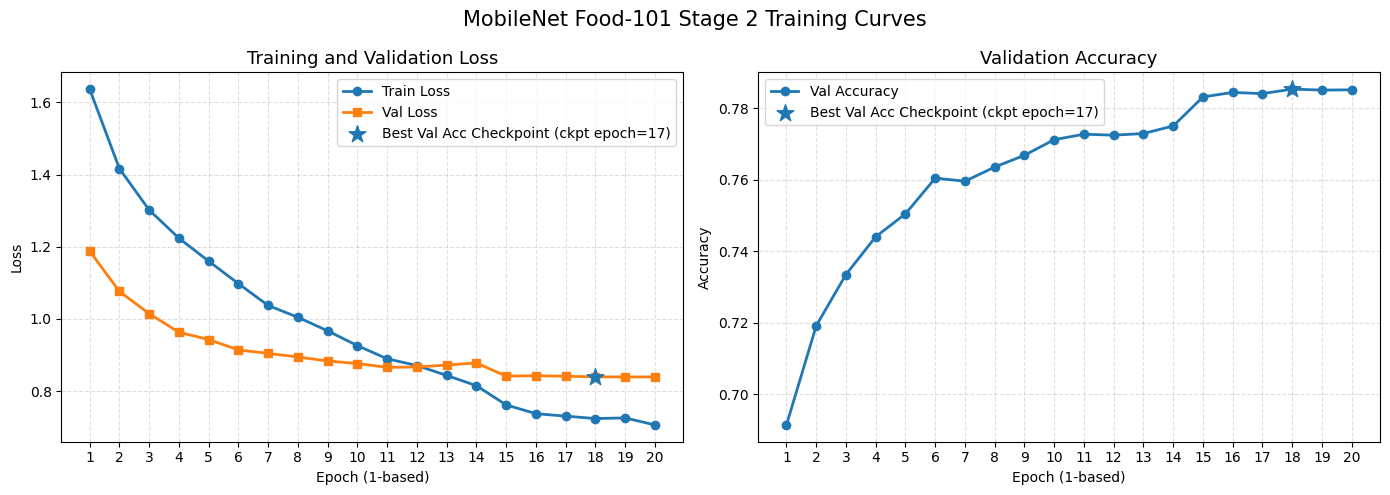

In [35]:
# Reload the Stage 2 CSV logs so the fine-tuning curves can be reproduced from disk.
df = pd.read_csv("../artifacts/logs/food101_tl_stage2/version_0/metrics.csv")

# Plot the Stage 2 loss and validation-accuracy curves.
stage2_curves_fig, stage2_curves_axes = helper_utils.plot_training_curves(
    df=df,
    title="MobileNet Food-101 Stage 2 Training Curves",
)

In [ ]:
# Save the Stage 2 curve figure explicitly so the save step remains robust.
helper_utils.save_figure_to_artifacts("mobilenet_stage2_training_curves", fig=stage2_curves_fig)

### 6.5 Inspect Stage 2 Predictions

Sample a fixed subset of validation images to inspect where the best Stage 2 model is confident and where it still makes mistakes.


In [ ]:
# Visualize a fixed random subset of validation images from the best Stage 2 checkpoint.
fig, axes = helper_utils.show_random_validation_predictions(trained_trainer_tl_stage2, dm, random_seed=42)

# Save the prediction panel with a Stage 2-specific name so it does not overwrite
# the earlier baseline visualization.
helper_utils.save_figure_to_artifacts("stage2_val_predictions", fig=fig)

# The saved figure can be reused in the final report even if notebook output is cleared.

### 6.6 Compare Stage 1 and Stage 2

Place both transfer-learning stages in one view so the extra value of fine-tuning is easy to compare.


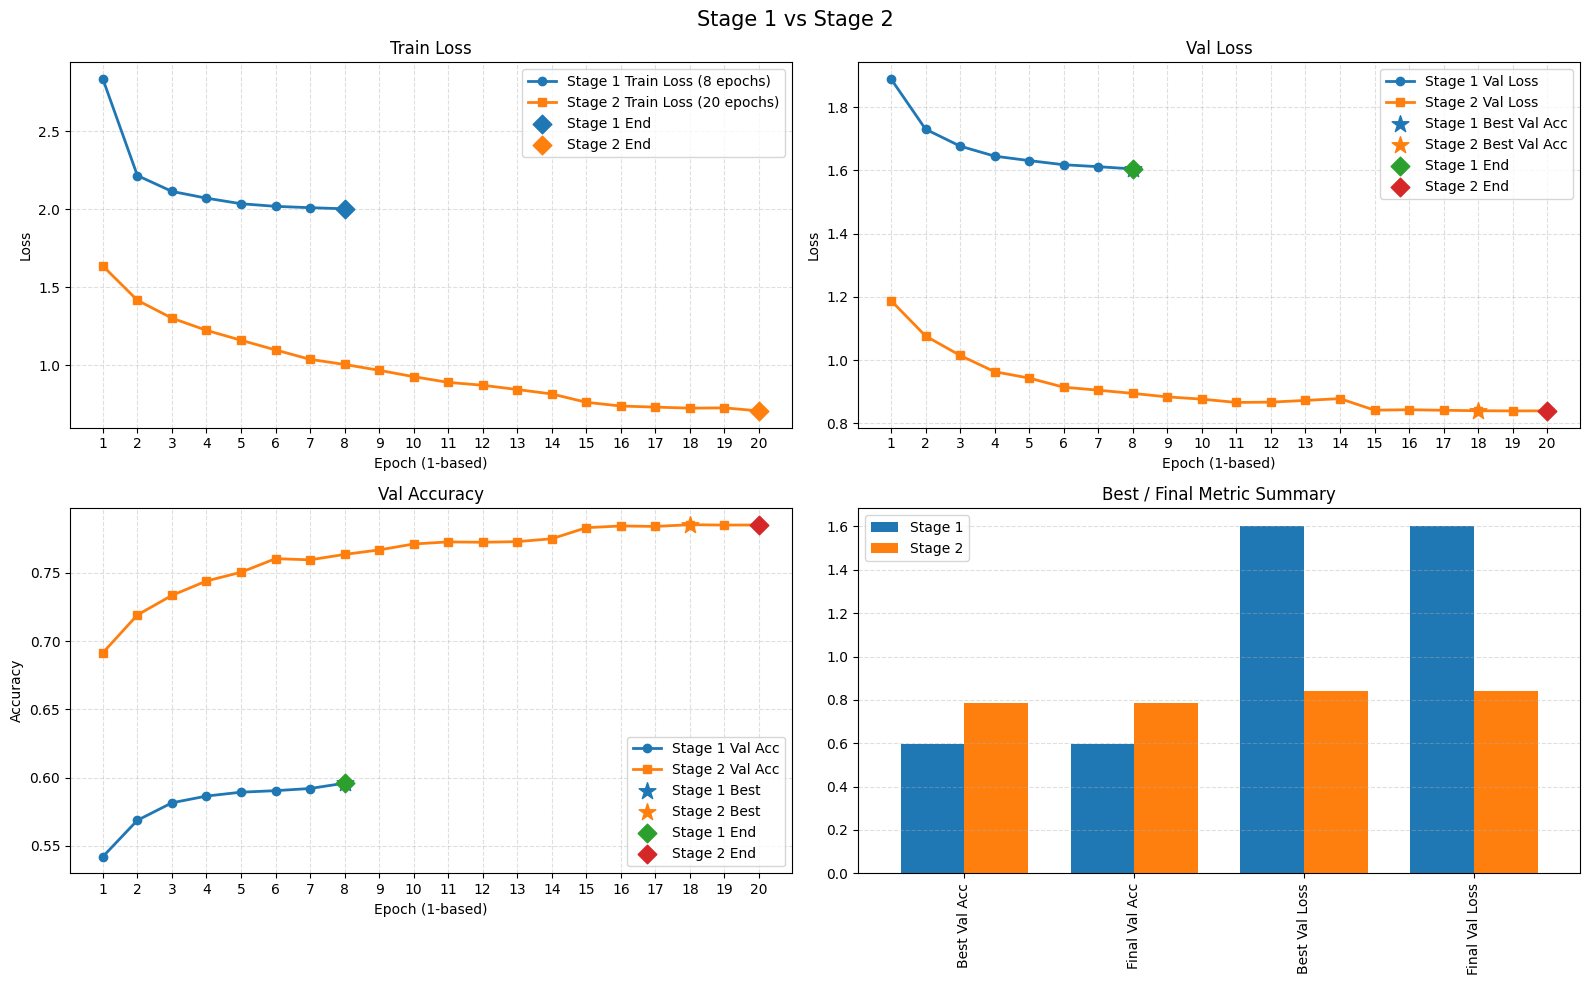

,stage,best_epoch,best_val_acc,best_val_loss,train_loss_at_best,final_epoch,final_train_loss,final_val_loss,final_val_acc
0,Stage 1,8,0.595842,1.604414,2.003683,8,2.003683,1.604414,0.595842
1,Stage 2,18,0.785281,0.839602,0.724005,20,0.706315,0.839344,0.785083
2,Stage 2 - Stage 1,10,0.189439,-0.764812,-1.279678,12,-1.297368,-0.765069,0.189241


In [5]:
# Load the epoch-level CSV logs for both transfer-learning stages.
stage1_df = pd.read_csv("../artifacts/logs/food101_tl_stage1/version_0/metrics.csv")
stage2_df = pd.read_csv("../artifacts/logs/food101_tl_stage2/version_0/metrics.csv")

# Plot the side-by-side comparison and return a compact summary table for the notebook.
results = helper_utils.compare_stage_training_runs(stage1_df, stage2_df)
stage_comparison_fig = results["fig"]
results["summary"]

In [ ]:
# Save the comparison figure explicitly instead of relying on the current figure.
helper_utils.save_figure_to_artifacts("mobilenet_stage2_summary_curves", fig=stage_comparison_fig)

## 7. ConvNeXt-Tiny Two-Stage Transfer Learning

`MobileNetV3-Large` provides a lightweight transfer-learning baseline, but its accuracy ceiling is limited. In this section we repeat the same two-stage recipe with a stronger pretrained `ConvNeXt-Tiny` backbone to test whether the extra capacity improves validation accuracy under the same overall pipeline.


In [15]:
# Optional: uncomment to inspect the raw ConvNeXt-Tiny architecture.
# weights = tv_models.ConvNeXt_Tiny_Weights.DEFAULT

# conve_model = tv_models.convnext_tiny(weights=weights)
# print(conve_model)

In [16]:
def load_convnext_tiny_2stage_tl(num_classes):
    weights = tv_models.ConvNeXt_Tiny_Weights.DEFAULT
    model = tv_models.convnext_tiny(weights=weights)

    # Replace the classifier head to match the number of classes for the new task.
    num_ftrs = model.classifier[2].in_features
    new_classifier = nn.Linear(in_features=num_ftrs, out_features=num_classes)
    model.classifier[2] = new_classifier

    # Freeze the full network first.
    for param in model.parameters():
        param.requires_grad = False

    # Stage 1 trains only the new classifier head.
    for param in model.classifier[-1].parameters():
        param.requires_grad = True

    return model

In [17]:
# Build a standalone Stage 1 backbone so we can inspect the freeze / unfreeze setup.
conve_model_stage_1 = load_convnext_tiny_2stage_tl(101)

Parameters in features[0] are frozen: True
Parameters in features[-1] are unfrozen: False
Parameters in the classifier are unfrozen: True


In [18]:
# Verify that an early feature block remains frozen in Stage 1.
print(f"Parameters in features[0] are frozen: {not next(conve_model_stage_1.features[0].parameters()).requires_grad}")

# Verify that late backbone blocks are still frozen because Stage 1 trains only the head.
print(f"Parameters in features[-1] are frozen: {not next(conve_model_stage_1.features[-1].parameters()).requires_grad}")

# Verify that the classifier head is trainable.
print(f"Parameters in the classifier are unfrozen: {conve_model_stage_1.classifier[2].weight.requires_grad}")

In [19]:
# Wrap the ConvNeXt Stage 1 model inside the reusable LightningModule helper so
# later experiments can reuse the same optimization and logging interface.
conve_stage1_classifier = utils.Create_flexible_Food101Classifier(
    num_classes=101,
    learning_rate=1e-3,
    weight_decay=1e-4,
    model=conve_model_stage_1,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
)

--- LightningModule Components ---
Model Architecture: ConvNeXt
Classifier Head:    Linear(in_features=768, out_features=101, bias=True)
Loss Function:      CrossEntropyLoss
Accuracy Metric:    MulticlassAccuracy(num_classes=101)
Optimizer:          AdamW
LR Scheduler:       ReduceLROnPlateau


In [ ]:
# Confirm that the reusable LightningModule exposes the expected model,
# metric, optimizer, and scheduler before launching Stage 1 training.
verify_model = conve_stage1_classifier

# Get the optimizer and scheduler.
optimizer_config = verify_model.configure_optimizers()
optimizer = optimizer_config["optimizer"]
scheduler = optimizer_config["lr_scheduler"]["scheduler"]

# --- Print the results to verify ---
print("--- LightningModule Components ---")
print(f"Model Architecture: {verify_model.model.__class__.__name__}")
print(f"Classifier Head:    {verify_model.model.classifier[-1]}")
print(f"Loss Function:      {verify_model.loss_fn.__class__.__name__}")
print(f"Accuracy Metric:    {verify_model.accuracy.__class__.__name__}(num_classes={verify_model.accuracy.num_classes})")
print(f"Optimizer:          {optimizer.__class__.__name__}")
print(f"LR Scheduler:       {scheduler.__class__.__name__}")

### 7.1 Stage 1: Train the Classifier Head

Stage 1 keeps the pretrained `ConvNeXt-Tiny` backbone frozen and warms up only the new Food-101 classifier head.


In [21]:
# Save only the best Stage 1 checkpoint, using validation accuracy as the selection criterion.
checkpoint_callback_conve_tl_stage1 = ModelCheckpoint(
    dirpath="../artifacts/checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="food101-conve_tl-stage1-{epoch:02d}-{val_acc:.4f}"
)

In [ ]:
# Record Stage 1 epoch-level metrics so the learning curves can be reloaded later.
csv_logger_conve_tl_stage1 = CSVLogger(
    save_dir="../artifacts/logs",
    name="food101_conve_tl_stage1"
)

In [23]:
# Run a one-batch dry run before the real Stage 1 training loop.
# Using a deep-copied model keeps this sanity check from mutating the actual
# classifier module that will be used for the full experiment.
verify_dm = Food101DataModule(data_dir=data_dir, batch_size=2)
verify_model = copy.deepcopy(conve_stage1_classifier)
num_epochs = 1
verify_callback = checkpoint_callback_conve_tl_stage1

# `dry_run=True` executes only a single batch, which is a fast way to catch
# shape, dataloader, and callback issues before spending time on training.
print("--- Verifying Training Run (Dry Run) ---")
trainer, verify_model = run_training(
    model=verify_model,
    data_module=verify_dm,
    num_epochs=num_epochs,
    callback=verify_callback,
    dry_run=True
)
print("The Trainer configured and ran a single batch without errors.")

In [ ]:
# Stage 1 is a head-only warm-up so Stage 2 can start from a stable classifier.
training_epochs = 10

In [ ]:
# Build the full Stage 1 training stack: datamodule, model, checkpointing, and logging.
# In this stage only the classifier head trains, so the logged metrics describe
# how well the new head adapts while the pretrained backbone stays frozen.
dm = Food101DataModule(data_dir=data_dir)
dm.setup()

# Reuse the prepared ConvNeXt Stage 1 LightningModule.
model = conve_stage1_classifier

# Launch the full Stage 1 fit and keep both the Trainer and the fitted model.
trained_trainer_conve_tl_stage1, trained_model_conve_tl_stage1 = run_training(
    model, dm, training_epochs, checkpoint_callback_conve_tl_stage1, csv_logger_conve_tl_stage1
)

print("--- Training Complete ---")

In [26]:
# Report which checkpoint achieved the highest validation accuracy during Stage 1 training.
print("Best checkpoint:")
print(trained_trainer_conve_tl_stage1.checkpoint_callback.best_model_path)

# Report the corresponding best validation accuracy tracked by the checkpoint callback.
print("Best val_acc:")
print(trained_trainer_conve_tl_stage1.checkpoint_callback.best_model_score)

Validation DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [00:47<00:00,  5.03it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.7303630113601685
        val_loss            1.0200477838516235
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'val_loss': 1.0200477838516235, 'val_acc': 0.7303630113601685}]


In [ ]:
# Reload the best checkpoint and evaluate it once more on the validation set.
# This gives us a clean validation summary for the best saved model.
best_ckpt_path = trained_trainer_conve_tl_stage1.checkpoint_callback.best_model_path

best_model = type(conve_stage1_classifier).load_from_checkpoint(
    best_ckpt_path,
    model=conve_model_stage_1,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
    num_classes=101,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

val_results = trained_trainer_conve_tl_stage1.validate(best_model, datamodule=dm)
print(val_results)

### 7.2 Review Stage 1 Curves

Inspect the head-only `ConvNeXt-Tiny` training curves before unfreezing deeper blocks.


In [ ]:
# Reload the Stage 1 CSV logs from disk so the curves can be recreated even
# after a kernel restart or after clearing notebook outputs.
df = pd.read_csv("../artifacts/logs/food101_conve_tl_stage1/version_0/metrics.csv")

# Plot training loss, validation loss, and validation accuracy for the head-only run.
stage1_curves_fig, stage1_curves_axes = helper_utils.plot_training_curves(
    df=df,
    title="ConvNeXt Food-101 Stage 1 Training Curves",
)

In [ ]:
# Save the Stage 1 curve figure explicitly so the save step remains robust.
helper_utils.save_figure_to_artifacts("conve_stage1_training_curves", fig=stage1_curves_fig)

### 7.3 Build Stage 2

Stage 2 starts from the learned Stage 1 checkpoint, unfreezes late `ConvNeXt-Tiny` feature blocks, and fine-tunes them with a smaller learning rate.


In [42]:
# Optionally inspect the fitted Stage 1 LightningModule before copying it into Stage 2.
# The full printout is long, so keep it commented unless you need to debug the architecture.

# print(trained_model_conve_tl_stage1)

In [43]:
# Create the Stage 2 LightningModule from a deep copy of the trained Stage 1 model.
# This preserves the learned weights while ensuring Stage 1 and Stage 2 do not
# share the same underlying module object.
conve_stage2_classifier = utils.Create_flexible_Food101Classifier(
    model=copy.deepcopy(trained_model_conve_tl_stage1.model),   # reuse stage1 weights without sharing the same object
    num_classes=101,
    learning_rate=4e-5,                    # use a smaller learning rate for fine-tuning
    weight_decay=5e-4,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
)

# Unfreeze the late ConvNeXt feature blocks so Stage 2 can refine deeper features.
for block in conve_stage2_classifier.model.features[4:]:
    for param in block.parameters():
        param.requires_grad = True

Parameters in features[0] are frozen: True
Parameters in features[-1] are unfrozen: True
Parameters in the classifier are unfrozen: True


In [44]:
# Verify that an early feature block remains frozen in Stage 2.
print(f"Parameters in features[0] are frozen: {not next(conve_stage2_classifier.model.features[0].parameters()).requires_grad}")

# Verify that a late feature block is unfrozen for Stage 2 fine-tuning.
print(f"Parameters in features[-1] are unfrozen: {next(conve_stage2_classifier.model.features[-1].parameters()).requires_grad}")

# Verify that the classifier head remains trainable.
print(f"Parameters in the classifier are unfrozen: {conve_stage2_classifier.model.classifier[2].weight.requires_grad}")

--- LightningModule Components ---
Model Architecture: ConvNeXt
Classifier Head:    Linear(in_features=768, out_features=101, bias=True)
Loss Function:      CrossEntropyLoss
Accuracy Metric:    MulticlassAccuracy(num_classes=101)
Optimizer:          AdamW
LR Scheduler:       ReduceLROnPlateau


In [ ]:
# Re-check the Stage 2 LightningModule after unfreezing layers so we know the
# optimizer and scheduler will see the intended fine-tuning configuration.
verify_model = conve_stage2_classifier

# Get the optimizer and scheduler.
optimizer_config = verify_model.configure_optimizers()
optimizer = optimizer_config["optimizer"]
scheduler = optimizer_config["lr_scheduler"]["scheduler"]

# --- Print the results to verify ---
print("--- LightningModule Components ---")
print(f"Model Architecture: {verify_model.model.__class__.__name__}")
print(f"Classifier Head:    {verify_model.model.classifier[-1]}")
print(f"Loss Function:      {verify_model.loss_fn.__class__.__name__}")
print(f"Accuracy Metric:    {verify_model.accuracy.__class__.__name__}(num_classes={verify_model.accuracy.num_classes})")
print(f"Optimizer:          {optimizer.__class__.__name__}")
print(f"LR Scheduler:       {scheduler.__class__.__name__}")

### 7.4 Stage 2: Fine-Tune Late Features

Fine-tune the last `ConvNeXt-Tiny` feature blocks together with the classifier head and track the best validation checkpoint.


In [77]:
def early_stopping():
    # Create the EarlyStopping callback used during Stage 2 fine-tuning.
    stop = EarlyStopping(
        # Monitor validation accuracy because Stage 2 is selected by best val_acc.
        monitor="val_acc",
        # Allow a few epochs for the unfrozen layers to settle after each update.
        patience=4,
        # Higher validation accuracy is better, so use max mode.
        mode="max",
        # Ignore tiny fluctuations and only count meaningful improvements.
        min_delta=0.002
    )
    return stop

In [78]:
# Instantiate the callback once so the final configuration is visible in the notebook.
verify_callback = early_stopping()

# --- Print the results to verify ---
print("--- EarlyStopping Configuration ---")
print(f"Metric to Monitor:     {verify_callback.monitor}")
print(f"Patience:              {verify_callback.patience}")
print(f"Mode:                  {verify_callback.mode}")
print(f"Min delta:             {verify_callback.min_delta}")

--- EarlyStopping Configuration ---
Metric to Monitor:     val_acc
Patience:              4
Mode:                  max
Min delta:             0.002


In [49]:
# Save only the best Stage 2 checkpoint, using validation accuracy as the selection criterion.
checkpoint_callback_conve_tl_stage2 = ModelCheckpoint(
    dirpath="../artifacts/checkpoints",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="food101-conve-tl-stage2-{epoch:02d}-{val_acc:.4f}"
)

In [ ]:
# Record Stage 2 epoch-level metrics so the fine-tuning curves can be reloaded later.
csv_logger_conve_tl_stage2 = CSVLogger(
    save_dir="../artifacts/logs",
    name="food101_conve_tl_stage2"
)

In [54]:
# Run the same safety check for Stage 2 before the real fine-tuning job.
# Deep-copying the module again avoids changing the actual Stage 2 model during verification.
verify_dm = Food101DataModule(data_dir=data_dir, batch_size=2)
verify_model = copy.deepcopy(conve_stage2_classifier)
num_epochs = 1
verify_callbacks = [early_stopping(), checkpoint_callback_conve_tl_stage2]

# A one-batch dry run quickly confirms that unfreezing, logging, and callbacks all work together.
print("--- Verifying Training Run (Dry Run) ---")
trainer, verify_model = run_training(
    model=verify_model,
    data_module=verify_dm,
    num_epochs=num_epochs,
    callbacks=verify_callbacks,
    dry_run=True
)
print("The Trainer configured and ran a single batch without errors.")

In [ ]:
# Cap the short ConvNeXt Stage 2 fine-tuning run at 15 epochs.
training_epochs = 15

# Combine early stopping and checkpointing so Stage 2 both stops sensibly and keeps
# the checkpoint with the highest validation accuracy.
stage2_callbacks = [early_stopping(), checkpoint_callback_conve_tl_stage2]

In [ ]:
# Rebuild the datamodule and launch the full Stage 2 fine-tuning run.
# This stage trains the classifier head together with the last unfrozen feature blocks.
dm = Food101DataModule(data_dir=data_dir)
dm.setup()

# Reuse the prepared Stage 2 LightningModule.
model = conve_stage2_classifier

# Fit the Stage 2 model while logging metrics and tracking the best val_acc checkpoint.
trained_trainer_conve_tl_stage2, trained_model_conve_tl_stage2 = run_training(
    model, dm, training_epochs, callbacks=stage2_callbacks, logger=csv_logger_conve_tl_stage2
)

print("--- Training Complete ---")

In [63]:
# Report which checkpoint achieved the highest validation accuracy during Stage 2 training.
print("Best checkpoint:")
print(trained_trainer_conve_tl_stage2.checkpoint_callback.best_model_path)

# Report the corresponding best validation accuracy tracked by the checkpoint callback.
print("Best val_acc:")
print(trained_trainer_conve_tl_stage2.checkpoint_callback.best_model_score)

Validation DataLoader 0: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 237/237 [00:48<00:00,  4.92it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_acc            0.8313531279563904
        val_loss            0.7055920362472534
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'val_loss': 0.7055920362472534, 'val_acc': 0.8313531279563904}]


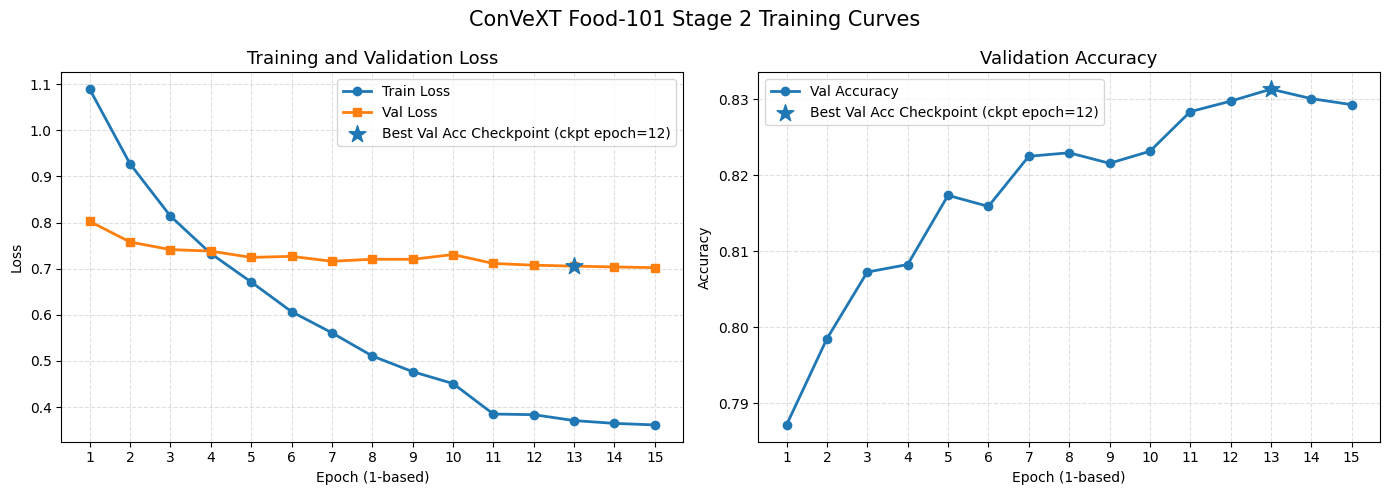

In [64]:
# Reload the best checkpoint and evaluate it once more on the validation set.
# This gives us a clean validation summary for the best saved model.
best_ckpt_path = trained_trainer_conve_tl_stage2.checkpoint_callback.best_model_path

best_model = type(conve_stage2_classifier).load_from_checkpoint(
    best_ckpt_path,
    load_model_fn=load_convnext_tiny_2stage_tl,
    optimizer_scheduler_fn=define_optimizer_and_scheduler,
    num_classes=101,
    learning_rate=4e-5,
    weight_decay=5e-4,
)

val_results = trained_trainer_conve_tl_stage2.validate(best_model, datamodule=dm)
print(val_results)

In [ ]:
# Reload the Stage 2 CSV logs so the fine-tuning curves can be reproduced from disk.
df = pd.read_csv("../artifacts/logs/food101_conve_tl_stage2/version_0/metrics.csv")

# Plot the Stage 2 loss and validation-accuracy curves.
stage2_curves_fig, stage2_curves_axes = helper_utils.plot_training_curves(
    df=df,
    title="ConvNeXt Food-101 Stage 2 Training Curves",
)

In [ ]:
# Save the Stage 2 curve figure explicitly so the save step remains robust.
helper_utils.save_figure_to_artifacts("conve_stage2_training_curves", fig=stage2_curves_fig)

### 7.5 Inspect Stage 2 Predictions

Use a fixed validation subset to qualitatively inspect the best `ConvNeXt-Tiny` Stage 2 checkpoint.


In [ ]:
# Visualize a fixed random subset of validation images from the best ConvNeXt Stage 2 checkpoint.
fig, axes = helper_utils.show_random_validation_predictions(best_model, dm, random_seed=42)

# Save the prediction panel with a Stage 2-specific name so it does not overwrite
# the earlier baseline visualization.
helper_utils.save_figure_to_artifacts("conve_stage2_val_predictions", fig=fig)

# The saved figure can be reused in the final report even if notebook output is cleared.

### 7.6 Compare Stage 1 and Stage 2

Summarize the `ConvNeXt-Tiny` two-stage experiment by comparing the Stage 1 and Stage 2 curves and checkpoint metrics.


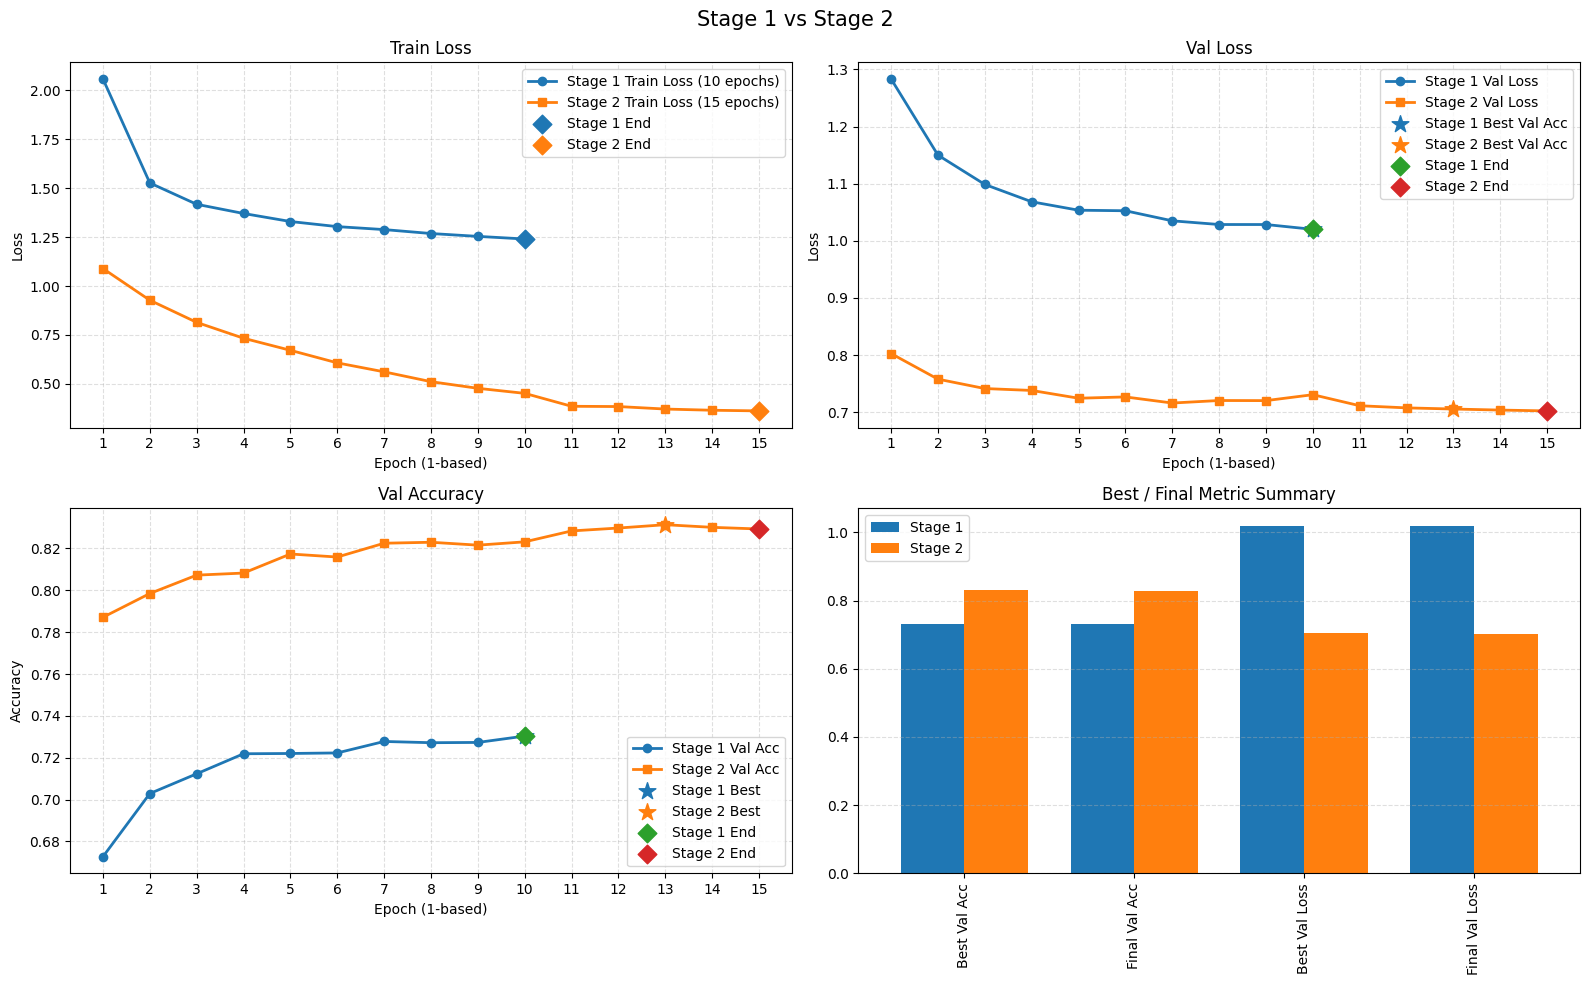

,stage,best_epoch,best_val_acc,best_val_loss,train_loss_at_best,final_epoch,final_train_loss,final_val_loss,final_val_acc
0,Stage 1,10,0.730363,1.020048,1.240487,10,1.240487,1.020048,0.730363
1,Stage 2,13,0.831353,0.705592,0.370728,15,0.361275,0.702315,0.829307
2,Stage 2 - Stage 1,3,0.100990,-0.314456,-0.869760,5,-0.879212,-0.317733,0.098944


In [80]:
# Load the epoch-level CSV logs for both transfer-learning stages.
stage1_df = pd.read_csv("../artifacts/logs/food101_conve_tl_stage1/version_0/metrics.csv")
stage2_df = pd.read_csv("../artifacts/logs/food101_conve_tl_stage2/version_0/metrics.csv")

# Plot the side-by-side comparison and return a compact summary table for the notebook.
results = helper_utils.compare_stage_training_runs(stage1_df, stage2_df)
stage_comparison_fig = results["fig"]
results["summary"]

In [ ]:
# Save the comparison figure explicitly instead of relying on the current figure.
helper_utils.save_figure_to_artifacts("conve_stage2_summary_curves", fig=stage_comparison_fig)